In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix

np.set_printoptions(precision=3, suppress=True)

RANDOM_STATE = 7
rng = np.random.default_rng(RANDOM_STATE)


In [2]:
# A toy house represented by four numerical features
# [area_in_m2, bedrooms, house_age_in_years, distance_to_city_centre_km]

x = np.array([120.5, 3.0, 12.0, 4.2])
print("Feature vector x: ", x)
print("Number of features D: ", x.shape[0])


Feature vector x:  [120.5   3.   12.    4.2]
Number of features D:  4


In [4]:
X_houses = np.array(
    [
        [120.5, 3, 12, 4.2],
        [85.0, 2, 5, 8.1],
        [150.0, 4, 20, 2.7],
    ]
)
print("Dataset shape (N,D): ", X_houses.shape)
print("Feature 1 for all examples: ", X_houses[:,0])



Dataset shape (N,D):  (3, 4)
Feature 1 for all examples:  [120.5  85.  150. ]


(1797, 64)
Image shape:  (8, 8)
Flattened vector shape:  (64,)
Label:  0


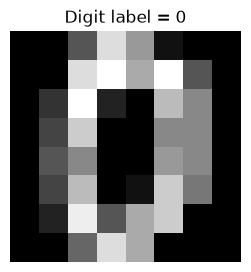

In [16]:
digits = load_digits()
print(digits.data.shape)
image0 = digits.images[0]
vector0 = digits.data[0]

print("Image shape: ", image0.shape)
print("Flattened vector shape: ", vector0.shape)
print("Label: ", digits.target[0])

plt.figure(figsize=(3,3))
plt.imshow(image0, cmap="gray")
plt.title(f"Digit label = {digits.target[0]}")
plt.axis("off")
plt.show()

In [9]:
a = np.array([2,1])
b = np.array([5,5])

print(" a + b = ", a+b)
print(" a - b = ", a - b)

dot_ab = np.dot(a,b) # dot product sum_i a_i b_i
norm_a = np.linalg.norm(a) # magnitude of a #euclidean norm

dist_ab = np.linalg.norm(a - b) # euclidean distance between a and b

print("<a,b> = ", dot_ab)
print("||a|| = ", norm_a)
print("||a-b|| = ", dist_ab)


 a + b =  [7 6]
 a - b =  [-3 -4]
<a,b> =  15
||a|| =  2.23606797749979
||a-b|| =  5.0


Mean / Centroid:  [2.125 1.875]


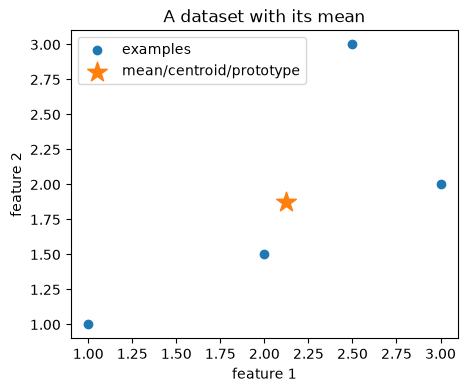

In [12]:
toy_points = np.array([
    [1,1],
    [2,1.5],
    [3,2],
    [2.5,3]
])

mean = toy_points.mean(axis=0)
print("Mean / Centroid: ", mean)

plt.figure(figsize=(5,4))
plt.scatter(toy_points[:,0], toy_points[:,1], label='examples')
plt.scatter(mean[0], mean[1], marker='*', s= 220, label="mean/centroid/prototype")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.title("A dataset with its mean")
plt.show()

In [14]:
def cosine_similarity(a,b):
    """cosine similarity gives directional alignment of two vectors"""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        raise ValueError("Undefined or zero vector")

    return np.dot(a,b)/denom

u = np.array([1,2])
v = np.array([2,4])
w = np.array([-2,1])
z = np.array([-1,-2])

print("cos(u,v) = ", cosine_similarity(u,v))
print("cos(u,w) = ", cosine_similarity(u,w))
print("cos(u,z) = ", cosine_similarity(u, z))
print("Euclidean distance u - v: ", np.linalg.norm(u-v))


cos(u,v) =  0.9999999999999998
cos(u,w) =  0.0
cos(u,z) =  -0.9999999999999998
Euclidean distance u - v:  2.23606797749979


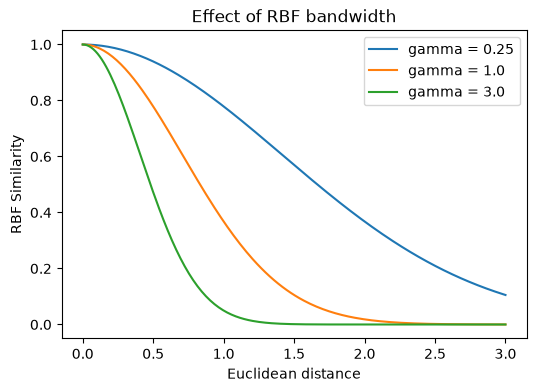

In [17]:
def rbf_similarity(a,b, gamma = 1.0):
    """similarity score between 0 and 1"""

    squared_dist = np.sum(np.asarray(a) - np.asarray(b)**2)
    return np.exp(-gamma * squared_dist)

distances = np.linspace(0,3,200)
# print("distances: ", distances)
plt.figure(figsize=(6,4))
for gamma in [0.25, 1.0, 3.0]:
    similarities = np.exp(-gamma * distances**2)
    plt.plot(distances, similarities, label = f"gamma = {gamma}")

plt.xlabel("Euclidean distance")
plt.ylabel("RBF Similarity")
plt.title("Effect of RBF bandwidth")
plt.legend()
plt.show()

In [19]:
people = np.array([
    [20, 50000],
    [60, 52000],
    [22, 100000]
])
labels = ["A", "B", "C"]


In [20]:
def pairwise_euclidean(X):
    # compute a NxN euclidean distance matrix using broadcasting
    diffs = X[:, None, :] - X[None, :, :]
    return np.sqrt(np.sum(diffs**2, axis=2))

raw_distances = pairwise_euclidean(people)

print("Raw Euclidean distance matrix: ")
print(raw_distances)
print("\n Nearest to A before scaling: ", labels[1 + np.argmin(raw_distances[0,1:])])

Raw Euclidean distance matrix: 
[[    0.     2000.4   50000.   ]
 [ 2000.4       0.    48000.015]
 [50000.    48000.015     0.   ]]

 Nearest to A before scaling:  B


In [21]:
scaler = StandardScaler()
people_scaled = scaler.fit_transform(people)
scaled_distances = pairwise_euclidean(people_scaled)

print("Standardized features")
print(people_scaled)

print("Euclidean distance matrix after standardization: ")
print(scaled_distances)

print("Nearest to A after scaling: ", labels[1 + np.argmin(scaled_distances[0, 1:])])

Standardized features
[[-0.761 -0.75 ]
 [ 1.413 -0.663]
 [-0.652  1.413]]
Euclidean distance matrix after standardization: 
[[0.    2.175 2.166]
 [2.175 0.    2.929]
 [2.166 2.929 0.   ]]
Nearest to A after scaling:  C


Raw numerical distance between 23 and 1:  22
Distance after cyclic encoding:  0.5176380902050424


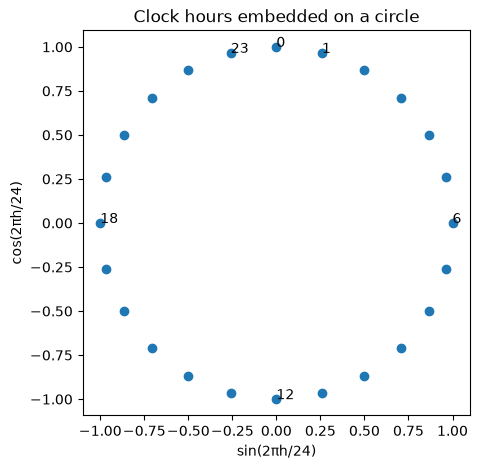

In [22]:
def encode_hour(hour):
    angle = 2 * np.pi * hour /24.0
    return np.array([np.sin(angle), np.cos(angle)])


h1, h2 = 23, 1

raw_hour_distance = abs(h2-h1)
cyclic_distance = np.linalg.norm(encode_hour(h1) - encode_hour(h2))

print("Raw numerical distance between 23 and 1: ", raw_hour_distance)
print("Distance after cyclic encoding: ", cyclic_distance)

hours = np.arange(24)
encoded = np.array([encode_hour(h) for h in hours])

plt.figure(figsize=(5,5))
plt.scatter(encoded[:,0], encoded[:,1])

for h in [0,1,6, 12, 18, 23]:
    plt.text(encoded[h,0], encoded[h,1], str(h))

plt.xlabel("sin(2πh/24)")
plt.ylabel("cos(2πh/24)")
plt.title("Clock hours embedded on a circle")
plt.axis("equal")
plt.show()


In [6]:
X_signal, y_signal = make_blobs(
    n_samples=120,
    centers=2,
    n_features=2,
    cluster_std=1.2,
    random_state=RANDOM_STATE,
)

# print(X_signal, y_signal)
query = X_signal[0]
true_label = y_signal[0]

def nearest_neighbour_index(X, q, exclude_index=None):
    distances = np.linalg.norm(X-q, axis=1)

    if exclude_index is not None:
        distances[exclude_index] = np.inf
    return np.argmin(distances)

nearest_neighbour_signal = nearest_neighbour_index(X_signal, query, exclude_index=0)
print("Query label: ", true_label)
print("Nearest-neighbour label using only signal features: ", y_signal[nearest_neighbour_signal])

Query label:  1
Nearest-neighbour label using only signal features:  1


In [ ]:
# Append many independent noise dimensions.
noise = rng.normal(size=(X_signal.shape[0], 100))
X_noisy = np.hstack([X_signal, noise])

nn_noisy = nearest_neighbour_index(X_noisy, X_noisy[0], exclude_index=0)

print(
    "Nearest-neighbor label after adding 100 irrelevant features:", y_signal[nn_noisy]
)
print("Did the identity of the nearest neighbor change?", nearest_neighbour_signal != nn_noisy)

# This is one glimpse of a broader high-dimensional phenomenon: 
# distance-based algorithms can become much less meaningful 
# when the representation contains irrelevant or badly scaled dimensions.


Nearest-neighbor label after adding 100 irrelevant features: 1
Did the identity of the nearest neighbor change? True


### Learning with Prototype

In [3]:
class LearningWithPrototypes:

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.classes_ = np.unique(y)
        self.prototypes_ = np.vstack([
            X[y == cls].mean(axis=0) for cls in self.classes_
        ])
        return self

    def distances(self, X):
        X = np.asarray(X, dtype=float)
        # Broadcasting
        # X[:, None, :] => (N, 1, D)
        # prototype_[None, :, :] => (1, K, D)
        # difference  => (N, K, D)
        diffs = X[:, None, :] - self.prototypes_[None, :, :]
        return np.sqrt(np.sum(diffs**2,axis=2))

    def predict(self, X):
        dists = self.distances(X)
        nearest_indices = np.argmin(dists, axis=1)
        return self.classes_[nearest_indices]

In [4]:
X_toy, y_toy = make_blobs(
    n_samples = 160,
    centers = 3,
    cluster_std=1.3,
    random_state=RANDOM_STATE,
)

lwp = LearningWithPrototypes().fit(X_toy,y_toy)

print("Classes: ", lwp.classes_)
print("Prototype matrix shape: ", lwp.prototypes_.shape)
print("Prototypes: \n", lwp.prototypes_)

Classes:  [0 1 2]
Prototype matrix shape:  (3, 2)
Prototypes: 
 [[-8.305  5.448]
 [-1.623  4.557]
 [ 9.659  0.69 ]]


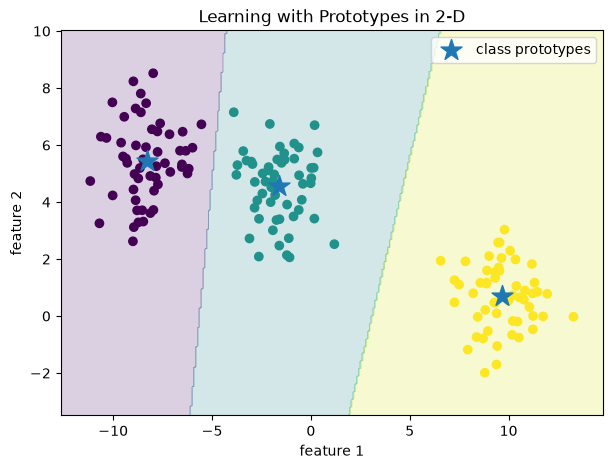

In [5]:
# Build a dense 2-D grid so we can visualize which prototype wins at each point.
x_min, x_max = X_toy[:, 0].min() - 1.5, X_toy[:, 0].max() + 1.5
y_min, y_max = X_toy[:, 1].min() - 1.5, X_toy[:, 1].max() + 1.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_pred = lwp.predict(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, grid_pred, alpha=0.2)
plt.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy)
plt.scatter(
    lwp.prototypes_[:, 0],
    lwp.prototypes_[:, 1],
    marker="*",
    s=250,
    label="class prototypes",
)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Learning with Prototypes in 2-D")
plt.legend()
plt.show()


In [6]:
# LwP on handwritten digits
digits = load_digits()
X = digits.data.astype(float)
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, stratify=y, random_state=RANDOM_STATE
)
print("Training shape: ", X_train.shape)
print("Test shape: ", X_test.shape)


Training shape:  (1257, 64)
Test shape:  (540, 64)


In [7]:
digit_lwp = LearningWithPrototypes().fit(X_train, y_train)
train_pred = digit_lwp.predict(X_train)
test_pred = digit_lwp.predict(X_test)

print("Training Accuracy: ", accuracy_score(y_train, train_pred))
print("Test Accuracy: ", accuracy_score(y_test, test_pred))

Training Accuracy:  0.9021479713603818
Test Accuracy:  0.9018518518518519


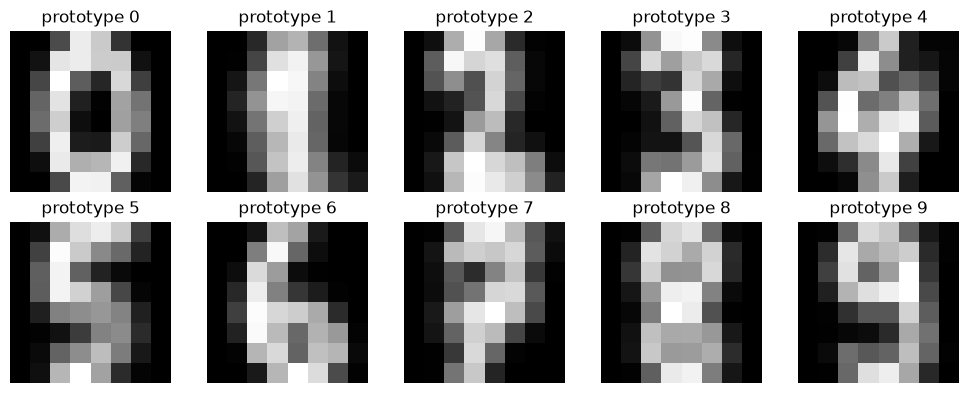

In [8]:
fig, axes = plt.subplots(2,5, figsize=(10,4))
for ax, cls, prototype in zip(
    axes.ravel(),
    digit_lwp.classes_,
    digit_lwp.prototypes_
):
    ax.imshow(prototype.reshape(8,8), cmap="gray")
    ax.set_title(f"prototype {cls}")
    ax.axis("off")

plt.tight_layout()
plt.show()

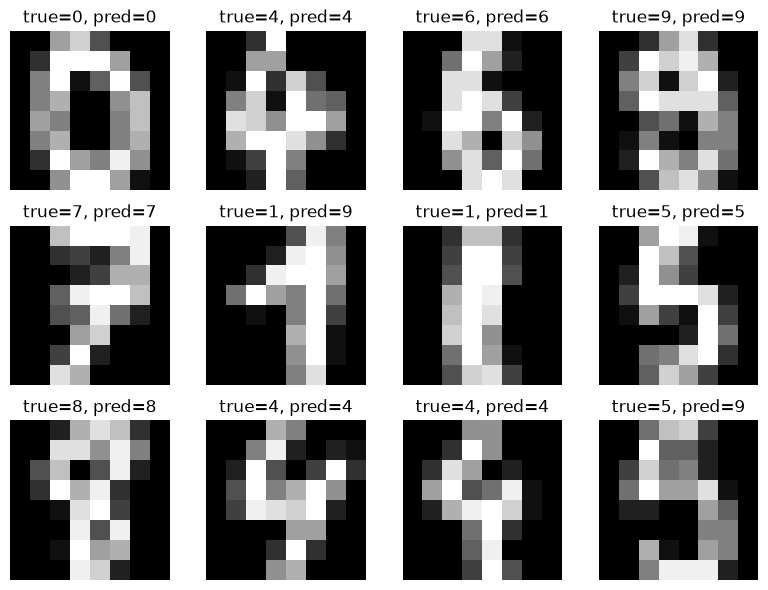

In [9]:
sample_indices = rng.choice(len(X_test), size=12, replace=False)

fig, axes = plt.subplots(3,4, figsize=(8,6))

for ax, idx in zip(axes.ravel(), sample_indices):
    ax.imshow(X_test[idx].reshape(8,8), cmap="gray")
    ax.set_title(f"true={y_test[idx]}, pred={test_pred[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

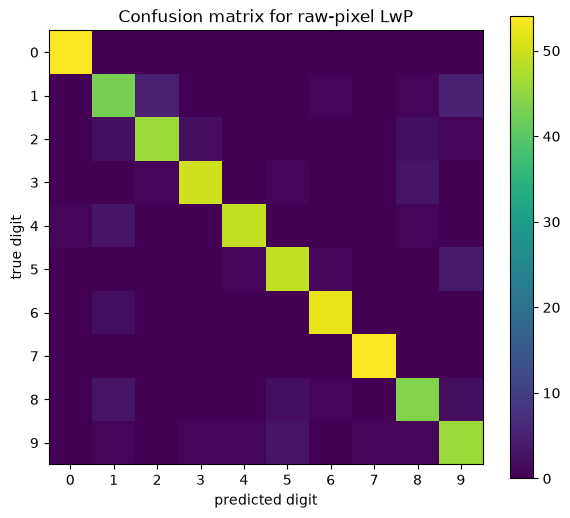

[[54  0  0  0  0  0  0  0  0  0]
 [ 0 43  5  0  0  0  1  0  1  5]
 [ 0  2 46  2  0  0  0  0  2  1]
 [ 0  0  1 50  0  1  0  0  3  0]
 [ 1  3  0  0 49  0  0  0  1  0]
 [ 0  0  0  0  1 49  1  0  0  4]
 [ 0  2  0  0  0  0 52  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  0]
 [ 0  3  0  0  0  2  1  0 44  2]
 [ 0  1  0  1  1  3  0  1  1 46]]


In [10]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("predicted digit")
plt.ylabel("true digit")
plt.xticks(range(10))
plt.yticks(range(10))
plt.title("Confusion matrix for raw-pixel LwP")
plt.show()
print(cm)

In [11]:
# Keep only digits 0 and 1 so the problem is binary.
mask_train = np.isin(y_train, [0, 1])
mask_test = np.isin(y_test, [0, 1])
print(mask_train[:5])
X01_train = X_train[mask_train]
y01_train = y_train[mask_train]

X01_test = X_test[mask_test]
y01_test = y_test[mask_test]

binary_lwp = LearningWithPrototypes().fit(X01_train, y01_train)

# By class order, prototype 0 corresponds to digit 0 and prototype 1 to digit 1.
mu0, mu1 = binary_lwp.prototypes_

# Derived linear discriminant:
# predict class 1 when w^T x + b > 0.
w = 2 * (mu1 - mu0)
b = np.dot(mu0, mu0) - np.dot(mu1, mu1)

linear_scores = X01_test @ w + b
pred_from_linear_rule = (linear_scores > 0).astype(int)

pred_from_distances = binary_lwp.predict(X01_test)

print(
    "All predictions identical?",
    np.array_equal(pred_from_linear_rule, pred_from_distances),
)
print("Binary test accuracy:", accuracy_score(y01_test, pred_from_distances))


[ True  True False False False]
All predictions identical? True
Binary test accuracy: 1.0


In [12]:
# LwP failes when a class is multimodal or has a complicated shape
X_moons, y_moons = make_moons(
    n_samples=400,
    noise=0.12,
    random_state=RANDOM_STATE,
)

moon_lwp = LearningWithPrototypes().fit(X_moons, y_moons)
moon_pred = moon_lwp.predict(X_moons)

print("Training accuracy on two moons:", accuracy_score(y_moons, moon_pred))


Training accuracy on two moons: 0.7875


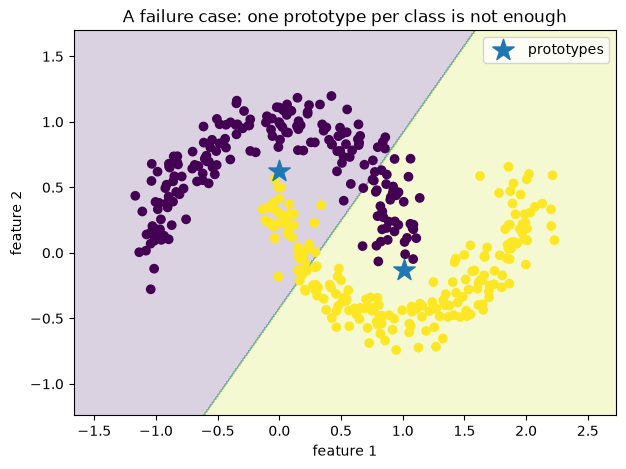

In [13]:
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_pred = moon_lwp.predict(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, grid_pred, alpha=0.2)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons)
plt.scatter(
    moon_lwp.prototypes_[:, 0],
    moon_lwp.prototypes_[:, 1],
    marker="*",
    s=260,
    label="prototypes",
)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("A failure case: one prototype per class is not enough")
plt.legend()
plt.show()


In [18]:
from sklearn.cluster import KMeans

class MultiPrototypeClassifier:

    def __init__(self, prototypes_per_class = 2, random_state=0):
        self.prototypes_per_class = prototypes_per_class
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)

        prototypes = []
        prototype_labels = []

        for cls in self.classes_:
            X_cls = X[y==cls]

            km = KMeans(
                n_clusters=self.prototypes_per_class,
                n_init=10,
                random_state=self.random_state
            )
            km.fit(X_cls)

            prototypes.append(km.cluster_centers_)
            prototype_labels.extend([cls]*self.prototypes_per_class)

        self.prototypes_ = np.vstack(prototypes)
        self.prototype_labels_ = np.array(prototype_labels)
        return self

    def predict(self, X):
        diffs = X[:, None, :] - self.prototypes_[None, :, :]
        dists = np.sqrt(np.sum(diffs**2, axis=2))
        nearest_neighbour = np.argmin(dists, axis=1)
        return self.prototype_labels_[nearest_neighbour]

In [26]:
multi_proto = MultiPrototypeClassifier(
    prototypes_per_class=3,
    random_state=RANDOM_STATE
).fit(X_moons, y_moons)

multi_pred = multi_proto.predict(X_moons)
print("Training accuracy with 3 prototypes per class: ", accuracy_score(y_moons, multi_pred))

Training accuracy with 3 prototypes per class:  0.985


In [27]:
# config 1 : raw pixels + euclidean distance
# config 2 : standardized pixels + euclidean distance
# config 3 : low-dim PCA + euclidean distance

def evaluate_lwp(X_train_rep, X_test_rep, y_train, y_test, name):
    model = LearningWithPrototypes().fit(X_train_rep, y_train)
    train_accuracy = accuracy_score(
        y_train,
        model.predict(X_train_rep)
    )

    test_accuracy = accuracy_score(
        y_test,
        model.predict(X_test_rep)
    )
    return {
        "configuration": name,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy
    }


In [37]:
results = []

results.append(evaluate_lwp(X_train, X_test, y_train, y_test, "Raw pixels + Euclidean"))

pixel_scaler = StandardScaler()
X_train_std = pixel_scaler.fit_transform(X_train)
X_test_std = pixel_scaler.fit_transform(X_test)

results.append(evaluate_lwp(
    X_train_std, X_test_std, y_train, y_test, 
    "Standardized pixel + Euclidean"
))


In [38]:
n_components = 30
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
results.append(
    evaluate_lwp(
        X_train_pca, X_test_pca, y_train, y_test, "30-D PCA features + Euclidean"
    )
)

In [39]:
for row in results:
    print(row)

{'configuration': 'Raw pixels + Euclidean', 'train_accuracy': 0.9021479713603818, 'test_accuracy': 0.9018518518518519}
{'configuration': 'Standardized pixel + Euclidean', 'train_accuracy': 0.9005568814638027, 'test_accuracy': 0.8796296296296297}
{'configuration': '30-D PCA features + Euclidean', 'train_accuracy': 0.8989657915672236, 'test_accuracy': 0.9037037037037037}


In [41]:
def predict_lwp_with_rbf(X, prototypes, classes, gamma = 0.05):
    diffs = X[:,None,:] - prototypes[None, :, :]
    sq_dists = np.sum(diffs**2, axis=2)
    similarities = np.exp(-gamma * sq_dists)
    most_similar = np.argmax(similarities, axis=1)
    return classes[most_similar]

raw_model = LearningWithPrototypes().fit(X_train, y_train)
pred_euclidean = raw_model.predict(X_test)

pred_rbf = predict_lwp_with_rbf(
    X_test, raw_model.prototypes_,
    raw_model.classes_,
    gamma=0.05
)
print("Are Euclidean and RBF predictions identical?", np.array_equal(pred_euclidean, pred_rbf))


Are Euclidean and RBF predictions identical? True
